<a href="https://colab.research.google.com/github/ariba8001-maker/Supervise-Machine-Learning-Model-/blob/main/linear_regression_(STUDENT_PERFORMANCE_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("/content/student_dataset_10000_rows.csv")
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [ ]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

In [ ]:
df.dtypes

,0
study_hours,int64
attendance,int64
sleep_hours,int64
internet_usage,int64
assignments_completed,int64
previous_score,int64
exam_score,float64
placement_status,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [ ]:
df.isnull().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [ ]:
df.duplicated().sum()

np.int64(0)

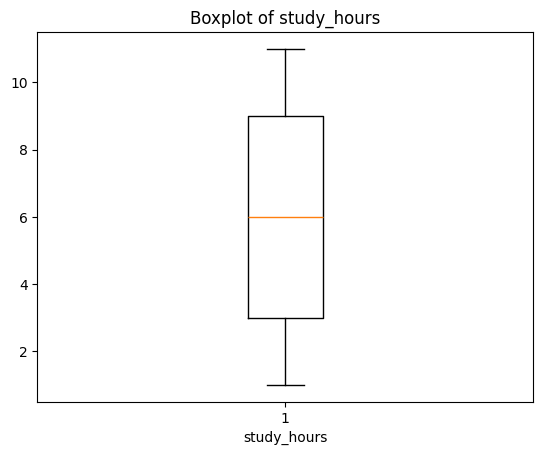

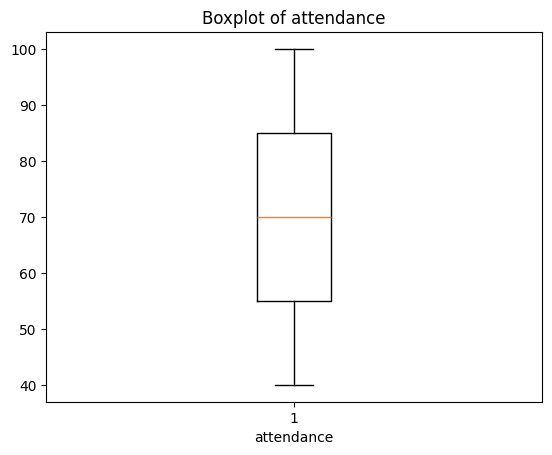

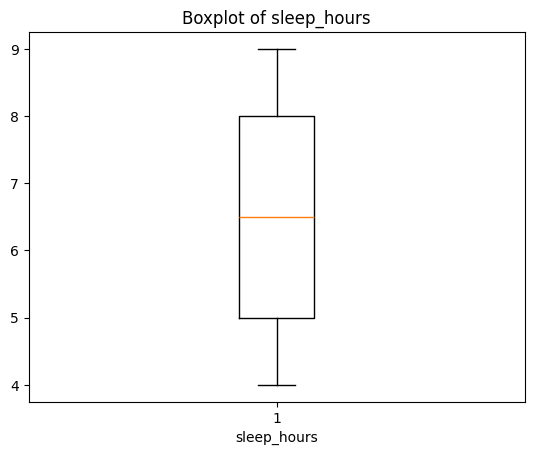

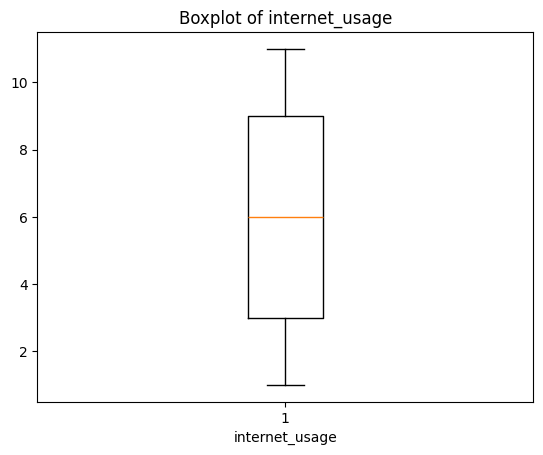

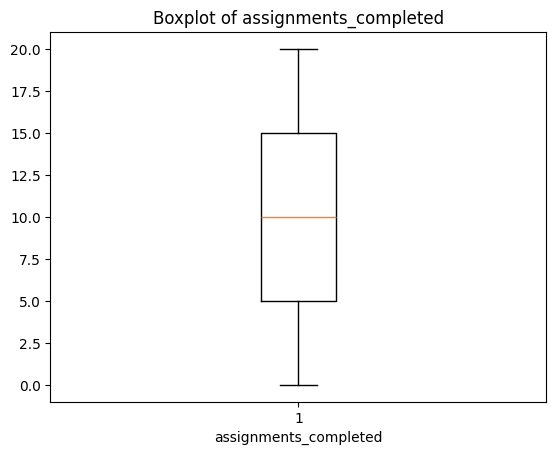

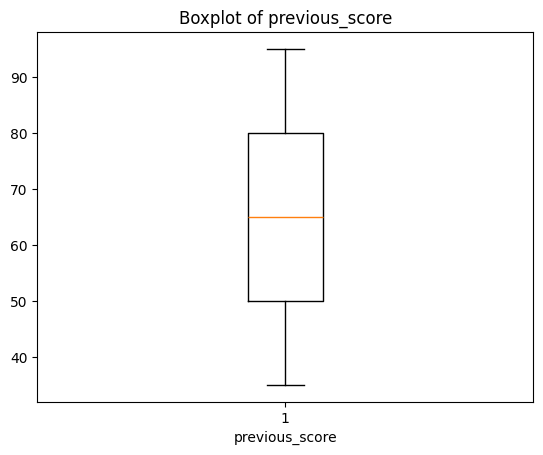

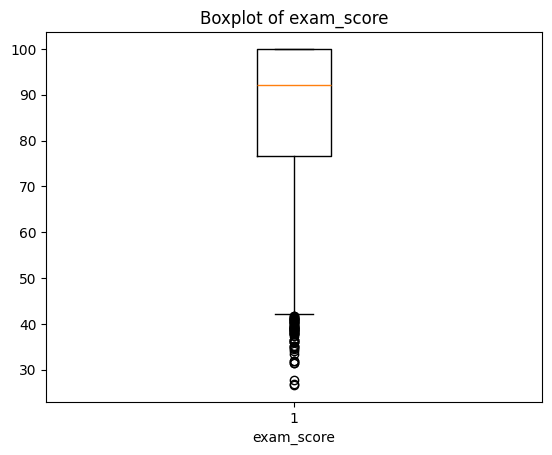

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

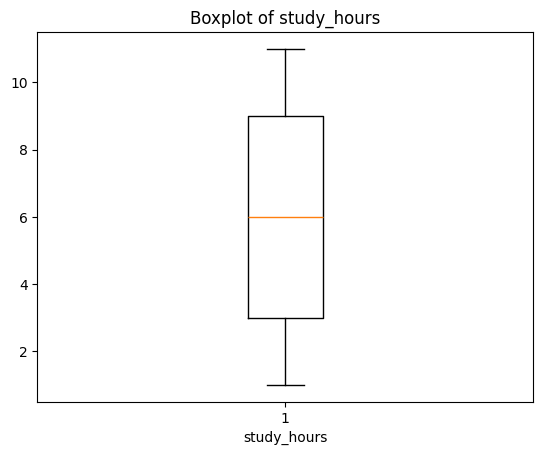

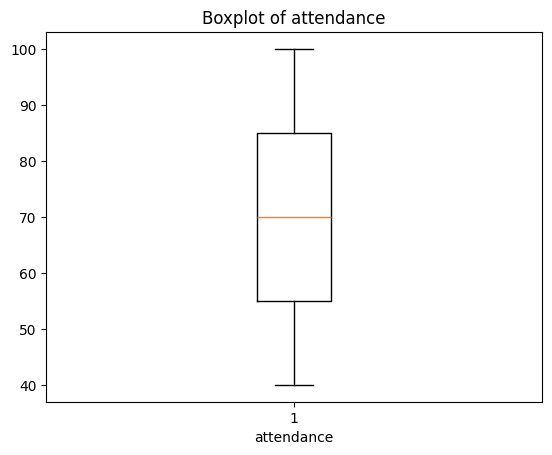

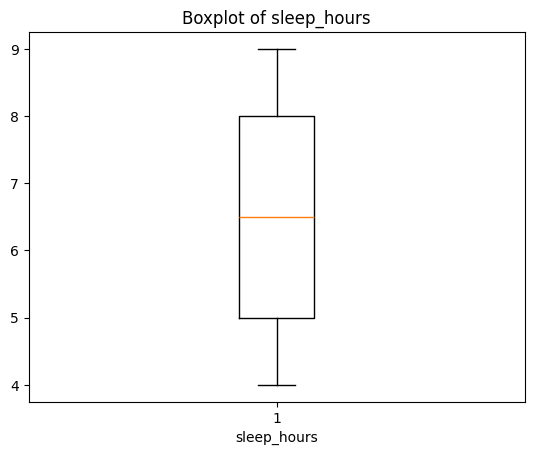

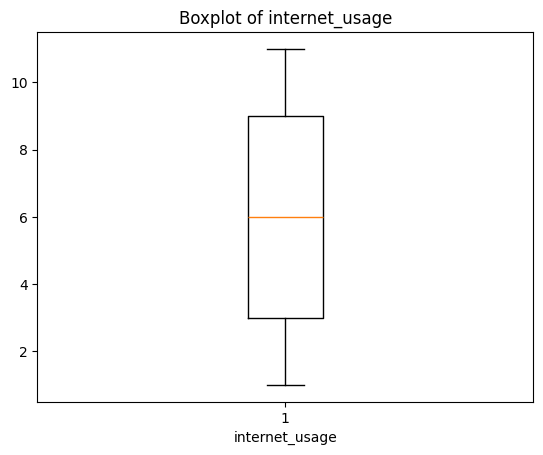

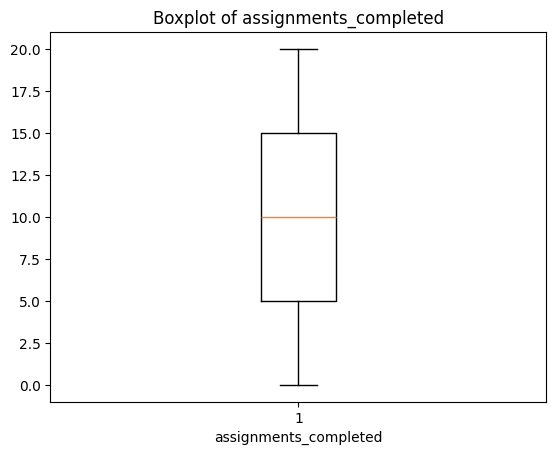

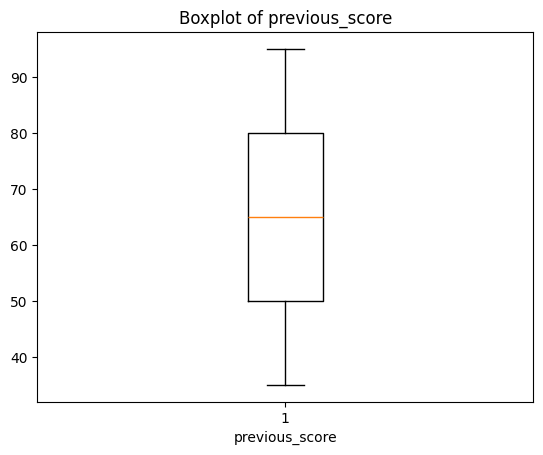

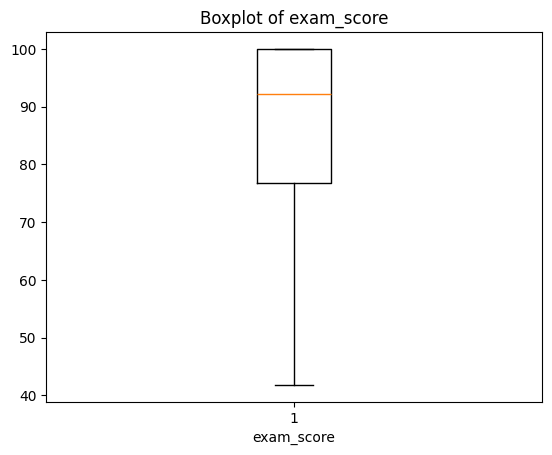

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

Encode Categorical Value
Label Encoding vs One Hot Encoding

In [ ]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [ ]:
ordinal_cols = ['study_hours','attendance','sleep_hours','internet_usage']
nominal_cols = ['placement_status']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ordinal_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [ ]:
df.dtypes

,0
study_hours,int64
attendance,int64
sleep_hours,int64
internet_usage,int64
placement_status,object
...,...
exam_score_99.96,bool
exam_score_99.97,bool
exam_score_99.98,bool
exam_score_99.99,bool


TRAIN TEST SPLIT


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('exam_score', axis=1)
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

MODEL TRAING

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

MODEL PREDICTION

In [ ]:
y_pred = model.predict(X_test)

MODEL EVALUATION

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8183823587492545
MAE: 5.1520274917768765


ML TRAINING FLOW

In [ ]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.8119966477274989
Test Score: 0.8183823587492545


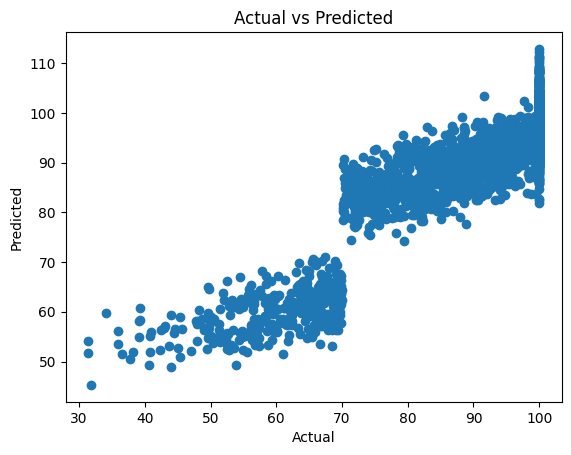

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

LASSO

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))

R2 Score: 0.7614961632423616
MAE: 5.898341019630214


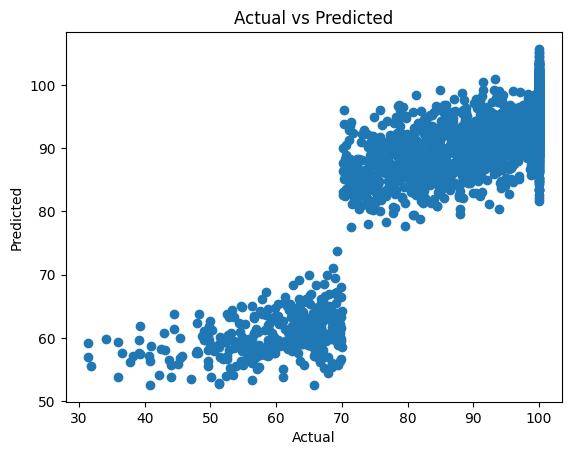

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

R2 Score: 0.8183719405345712
MAE: 5.152844339263854


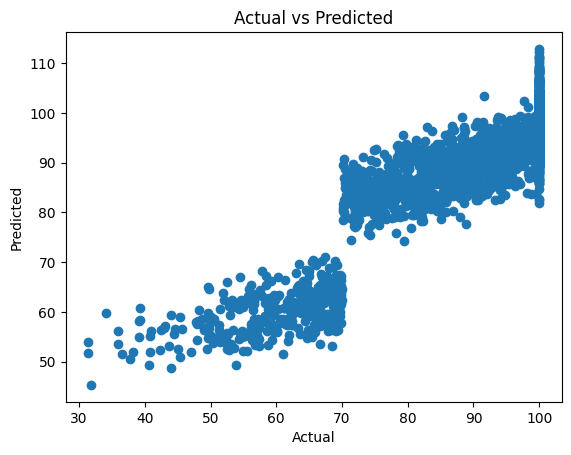

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha = 0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_elastic))
print("MAE:", mean_absolute_error(y_test, y_pred_elastic))

R2 Score: 0.7357324036049326
MAE: 6.155565521429022


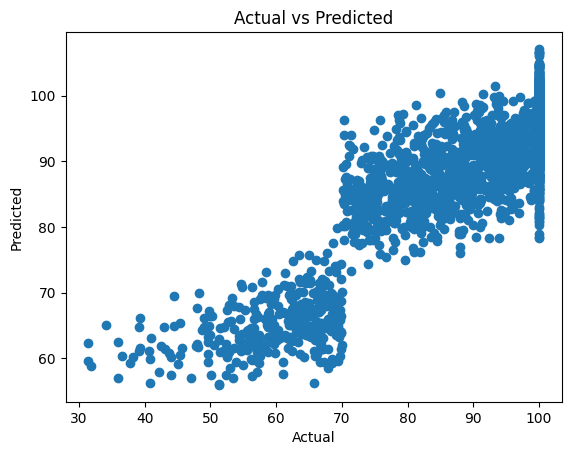

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()